## **Data Normalization, Unsupervised Learning, Confusion matrix**

In [163]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv') #make sure to replace with your data directory
#df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

In [164]:
df_features

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280


In [165]:
df_target

0      1
1      1
2      1
3      1
4      1
      ..
294    0
295    0
296    0
297    0
298    0
Name: DEATH_EVENT, Length: 299, dtype: int64

In [166]:
df_target.value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [167]:
df_target.value_counts(normalize=True)

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

In [168]:
df_features.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object')

## (1) Data Normalization 
- formula: $z = \frac{x - \mu}{\sigma}$
- z: z-score
- x: original value
- $\mu$: average value 
- $\sigma$: standard deviation 

In [169]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df_features_zscored = stats.zscore(df_features)
df_features_zscored

array([[ 1.19294523e+00, -8.71104775e-01,  1.65728387e-04, ...,
         7.35688190e-01, -6.87681906e-01, -1.62950241e+00],
       [-4.91279276e-01, -8.71104775e-01,  7.51463953e+00, ...,
         7.35688190e-01, -6.87681906e-01, -1.60369074e+00],
       [ 3.50832977e-01, -8.71104775e-01, -4.49938761e-01, ...,
         7.35688190e-01,  1.45416070e+00, -1.59078490e+00],
       ...,
       [-1.33339153e+00, -8.71104775e-01,  1.52597865e+00, ...,
        -1.35927151e+00, -6.87681906e-01,  1.90669738e+00],
       [-1.33339153e+00, -8.71104775e-01,  1.89039811e+00, ...,
         7.35688190e-01,  1.45416070e+00,  1.93250906e+00],
       [-9.12335403e-01, -8.71104775e-01, -3.98321274e-01, ...,
         7.35688190e-01,  1.45416070e+00,  1.99703825e+00]],
      shape=(299, 12))

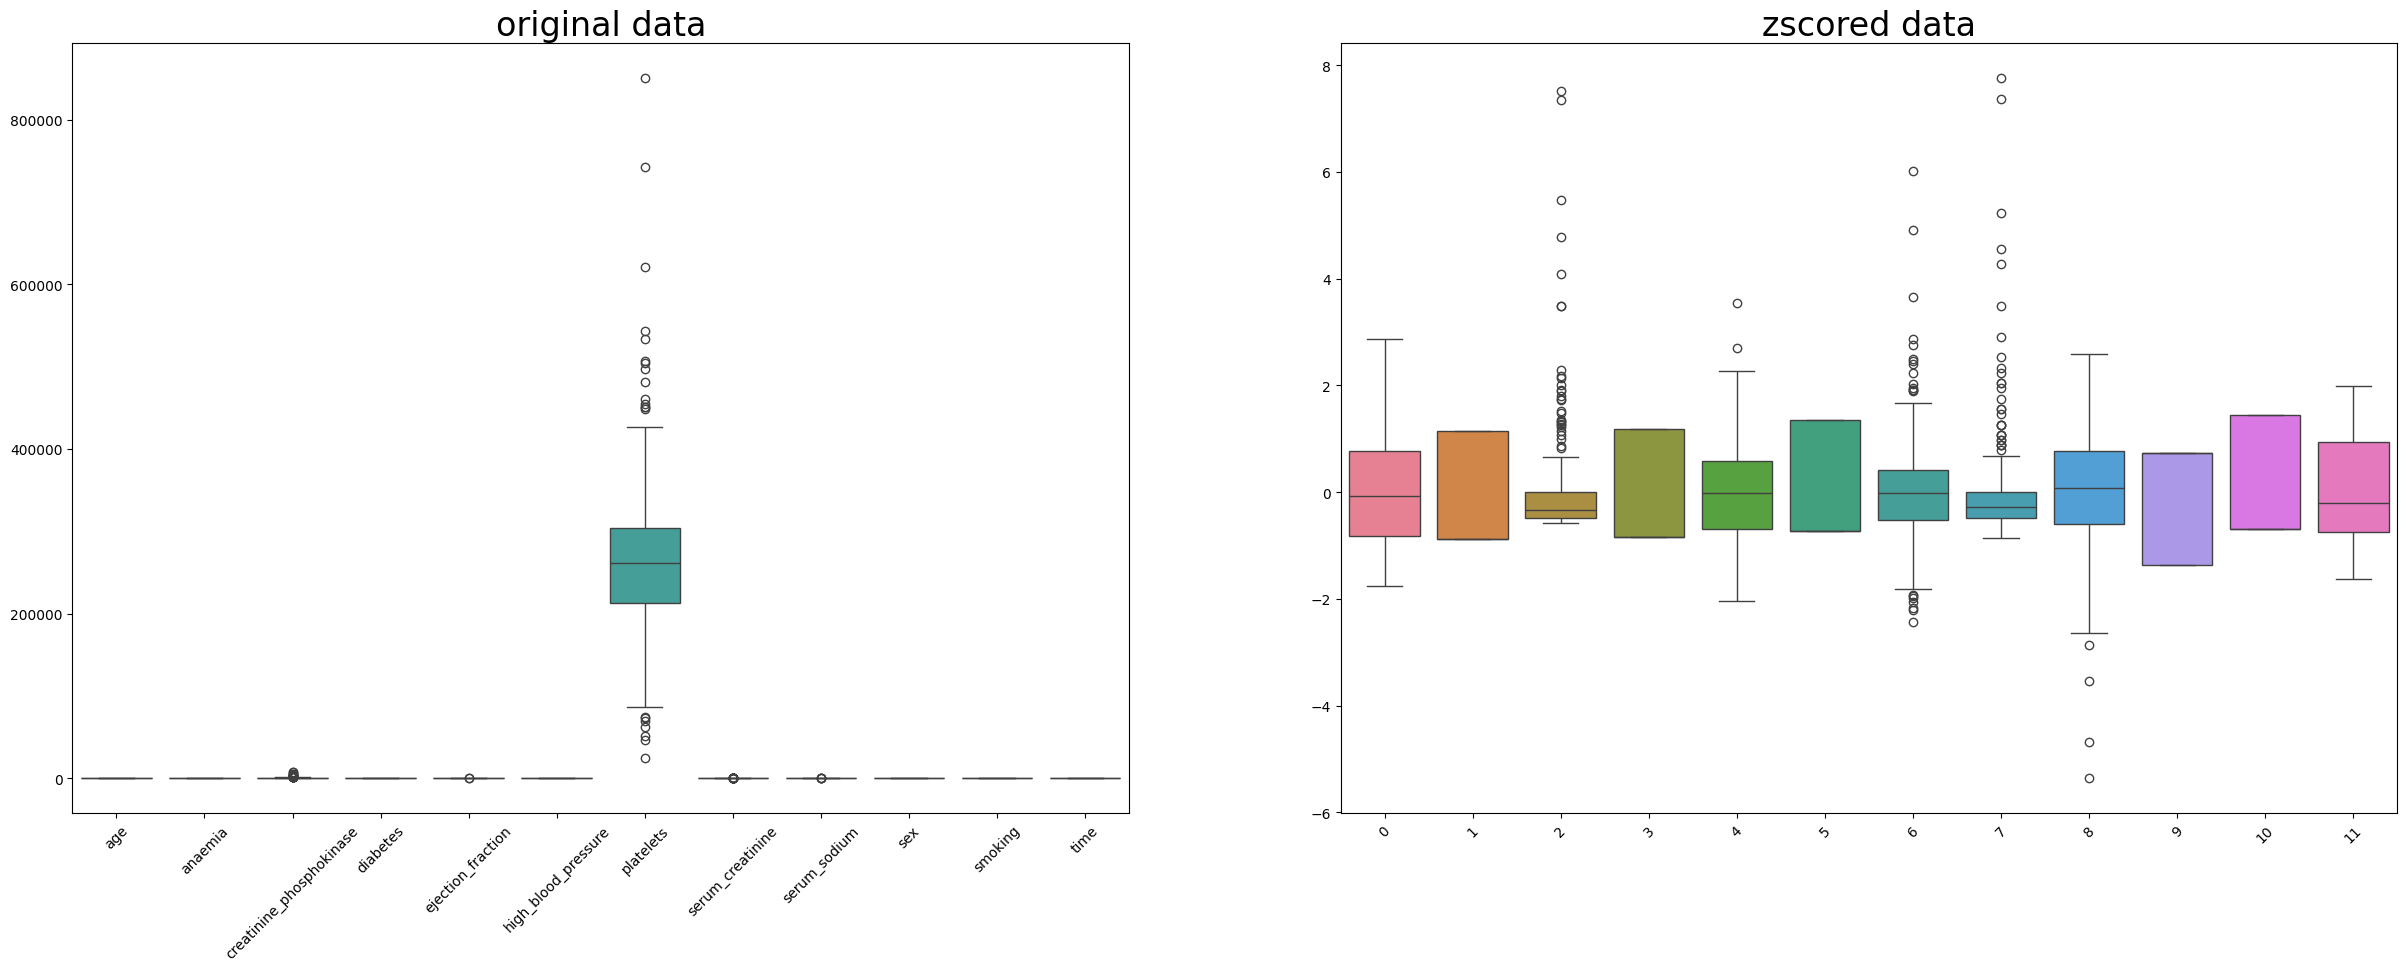

In [170]:
df_features_zscored = stats.zscore(df_features)

# plot both data including original and normalized
plt.figure(figsize=(30,10))
plt.subplot(1,2,1)
sns.boxplot(df_features)
plt.title('original data',size=24)
plt.xticks(rotation=45);  # rotate x-ticks by 45 degrees

plt.subplot(1,2,2)
sns.boxplot(df_features_zscored)
plt.title('zscored data', size = 24)
plt.xticks(rotation=45);  # rotate x-ticks by 45 degrees

## (2) Principal Component Analysis (PCA)

* The core problem PCA solves: to find the direction vector w that MAXIMIZES variance in n-dimensional data
* Written as an optimization problem:
  * maximize:  w^T Σ w
  * subject to: |w| = 1   (fix magnitude to 1 — we only care about direction)

  * where Σ = covariance matrix of the data (captures how much features vary together)

* Solving this with Lagrange multipliers gives:
  Σw = λw   ← this is the eigenvalue equation

* So the answer to "maximize variance" turns out to be:
  * w = eigenvector of Σ  →  the direction of maximum variance = PC
  * λ = eigenvalue of Σ   →  the amount of variance in that direction

* Properties:
  - PC1 = eigenvector with the LARGEST eigenvalue (most variance)
  - PC2 = eigenvector with the 2nd largest eigenvalue
  - All PCs are ORTHOGONAL to each other (no redundant information)
  - PC loadings are also orthogonal: pc1_loadings · pc2_loadings = 0

In [171]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=3) # 3 main components
# internally, pca.fit does:
# 1) compute covariance matrix Σ
# 2) eigendecomposition of Σ
# 3) sort eigenvectors by eigenvalue (largest first)
# 4) store in pca.components_
y = pca.fit_transform(df_features_zscored)
loadings = pca.components_.T

In [172]:
# shape (3, 12) —  3 eigenvectors, each are in 12 dimensions
# eigenvectors (the PC directions)
pca.components_

array([[ 0.04910096, -0.22818273,  0.16276474, -0.2846968 , -0.26181158,
        -0.19025566, -0.17021348,  0.0371995 , -0.0935383 ,  0.62237639,
         0.55387042, -0.00198151],
       [-0.49093212, -0.3204641 ,  0.23092179,  0.1515776 ,  0.04666221,
        -0.26518934,  0.1570159 , -0.4036002 ,  0.24087094, -0.03396914,
         0.00854975,  0.51058016],
       [ 0.18210792,  0.15043645, -0.08398492, -0.38923962,  0.44331474,
         0.22977573,  0.12455731, -0.26900254,  0.62552819,  0.092957  ,
         0.21630183, -0.04159205]])

In [173]:
# eigenvalues (variance per PC)
pca.explained_variance_ 

array([1.66854625, 1.5843945 , 1.27239806])

In [174]:
# eigenvalue / sum(eigenvalues) = variance ratio
pca.explained_variance_ratio_

array([0.13858049, 0.13159129, 0.10567855])

In [175]:
pca.components_.shape

(3, 12)

In [176]:
pca.n_components_

3

In [177]:
y.shape

(299, 3)

In [178]:
# loadings value: how strongly each feature contributes to each principal component
loadings.shape

(12, 3)

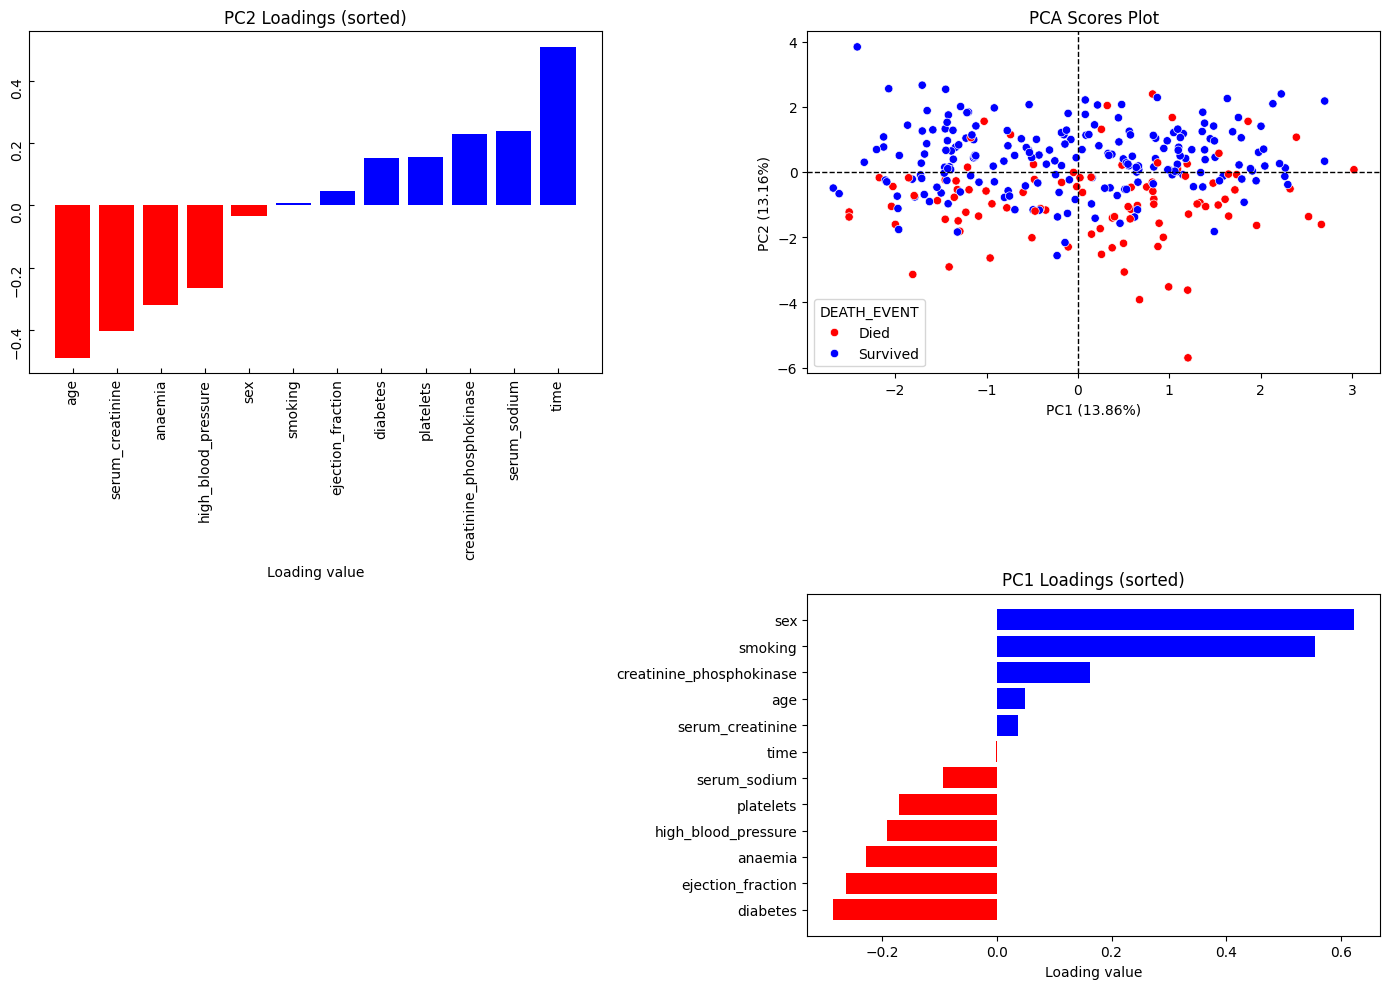

In [179]:
loadings = pca.components_.T
# pca.components_ are eigenvectors
# row = PC, col = features
# .T is transpose
feature_names = df_features.columns

# prepare loadings
# PC1 and PC2 are orthogonal
pc1_loadings = pd.Series(loadings[:, 0], index=feature_names).sort_values() # all feaure contributions to PC1
pc2_loadings = pd.Series(loadings[:, 1], index=feature_names).sort_values() # all feaure contributions to PC2

pc1_colors = ['red' if v < 0 else 'blue' for v in pc1_loadings]
pc2_colors = ['red' if v < 0 else 'blue' for v in pc2_loadings]
    # negative contribution = red
    # postivie contribution = blue

# create 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# (0,0) PC2 loadings bar chart — how much each feature contributes to PC2
axes[0,0].bar(pc2_loadings.index, pc2_loadings.values, color=pc2_colors)
axes[0,0].set_title('PC2 Loadings (sorted)')
axes[0,0].set_xlabel('Loading value')
axes[0,0].tick_params(axis='both', direction='in',rotation=90)

# (0,1) Scores plot — scatter of patients in PC1/PC2 space, colored by Died/Survived
color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y[:,0], y=y[:,1], hue=df_target.map({1: 'Died', 0: 'Survived'}), ax=axes[0,1], palette=color_mapping)
axes[0,1].axhline(0, linestyle='--', linewidth=1, color='black')
axes[0,1].axvline(0, linestyle='--', linewidth=1, color='black')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0,1].set_title('PCA Scores Plot')

# (1,1) PC1 loading bar chart — how much each feature contributes to PC1
axes[1,1].barh(pc1_loadings.index, pc1_loadings.values, color=pc1_colors) # barh = horizontal bar
axes[1,1].set_title('PC1 Loadings (sorted)')
axes[1,1].set_xlabel('Loading value')

# (1,0) empty subplot — left blank intentionally (just for layout balance)
axes[1,0].axis('off')

plt.tight_layout()
plt.show()

## (2-2) PCA on non-normalized data

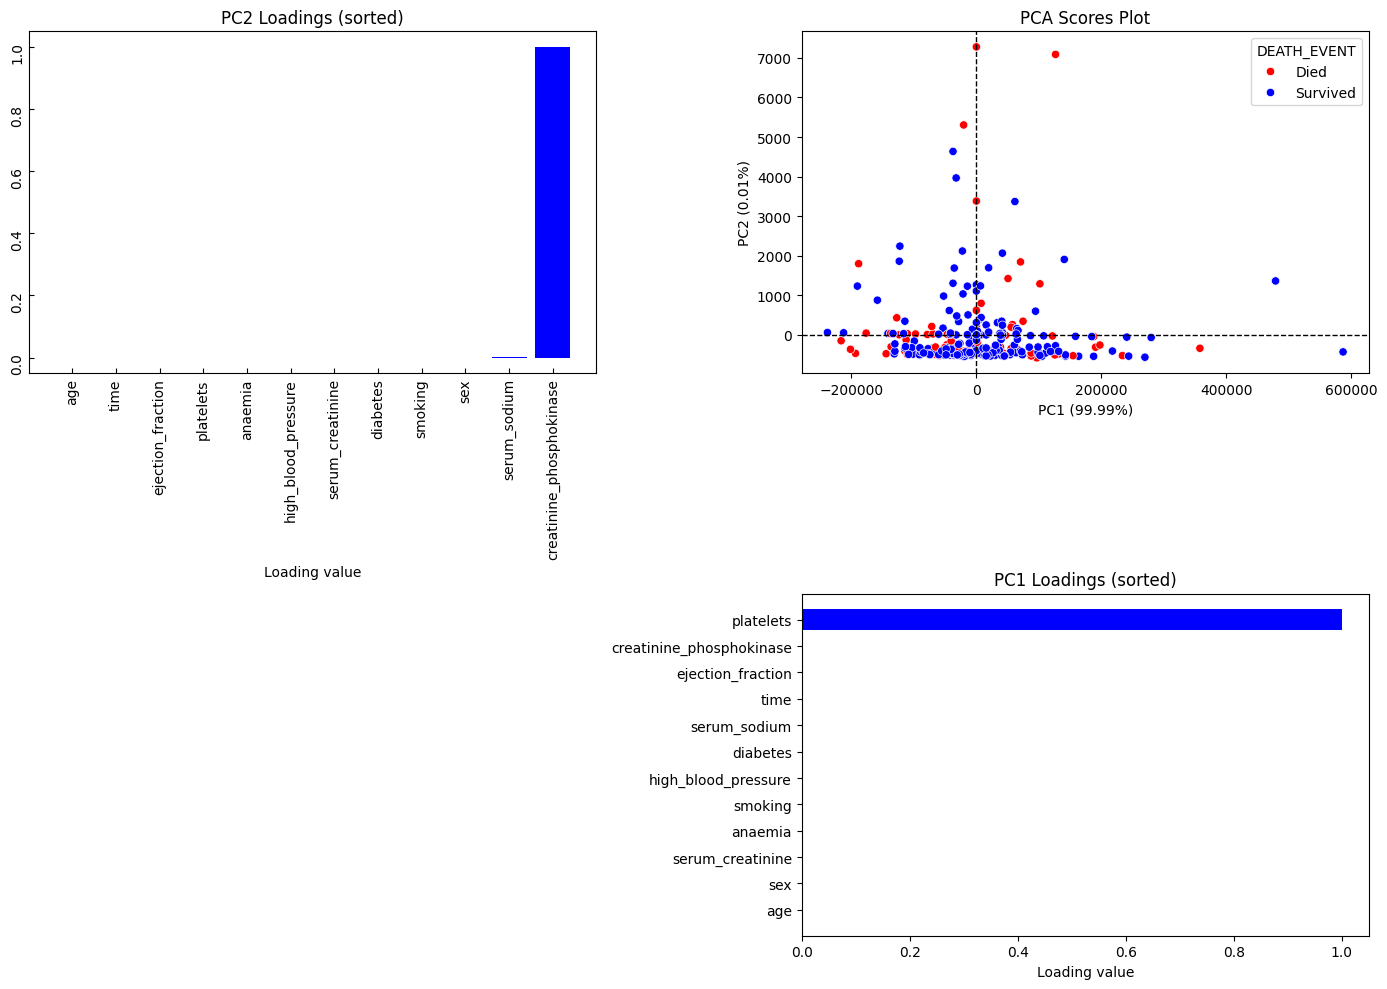

In [180]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca = pca.fit(df_features)
y= pca.fit_transform(df_features) # used non-normalized features
loadings = pca.components_.T
feature_names = df_features.columns

# prepare loadings
pc1_loadings = pd.Series(loadings[:, 0], index=feature_names).sort_values()
pc2_loadings = pd.Series(loadings[:, 1], index=feature_names).sort_values()

pc1_colors = ['red' if v < 0 else 'blue' for v in pc1_loadings]
pc2_colors = ['red' if v < 0 else 'blue' for v in pc2_loadings]

# create 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# (0,0) PC2 loadings
axes[0,0].bar(pc2_loadings.index, pc2_loadings.values, color=pc2_colors)
axes[0,0].set_title('PC2 Loadings (sorted)')
axes[0,0].set_xlabel('Loading value')
axes[0,0].tick_params(axis='both', direction='in',rotation=90)

# (0,1) scores plot
color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y[:,0], y=y[:,1], hue=df_target.map({1: 'Died', 0: 'Survived'}), ax=axes[0,1], palette=color_mapping)
axes[0,1].axhline(0, linestyle='--', linewidth=1, color='black')
axes[0,1].axvline(0, linestyle='--', linewidth=1, color='black')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0,1].set_title('PCA Scores Plot')

# (1,1) PC1 loadings
axes[1,1].barh(pc1_loadings.index, pc1_loadings.values, color=pc1_colors)
axes[1,1].set_title('PC1 Loadings (sorted)')
axes[1,1].set_xlabel('Loading value')

# (1,0) empty subplot
axes[1,0].axis('off')

plt.tight_layout()
plt.show()

# (2-3) PCA on normalized data without 'time' column

In [181]:
df_features_new = df_features.drop(columns=['time'])
df_features_new_zscored = stats.zscore(df_features_new)

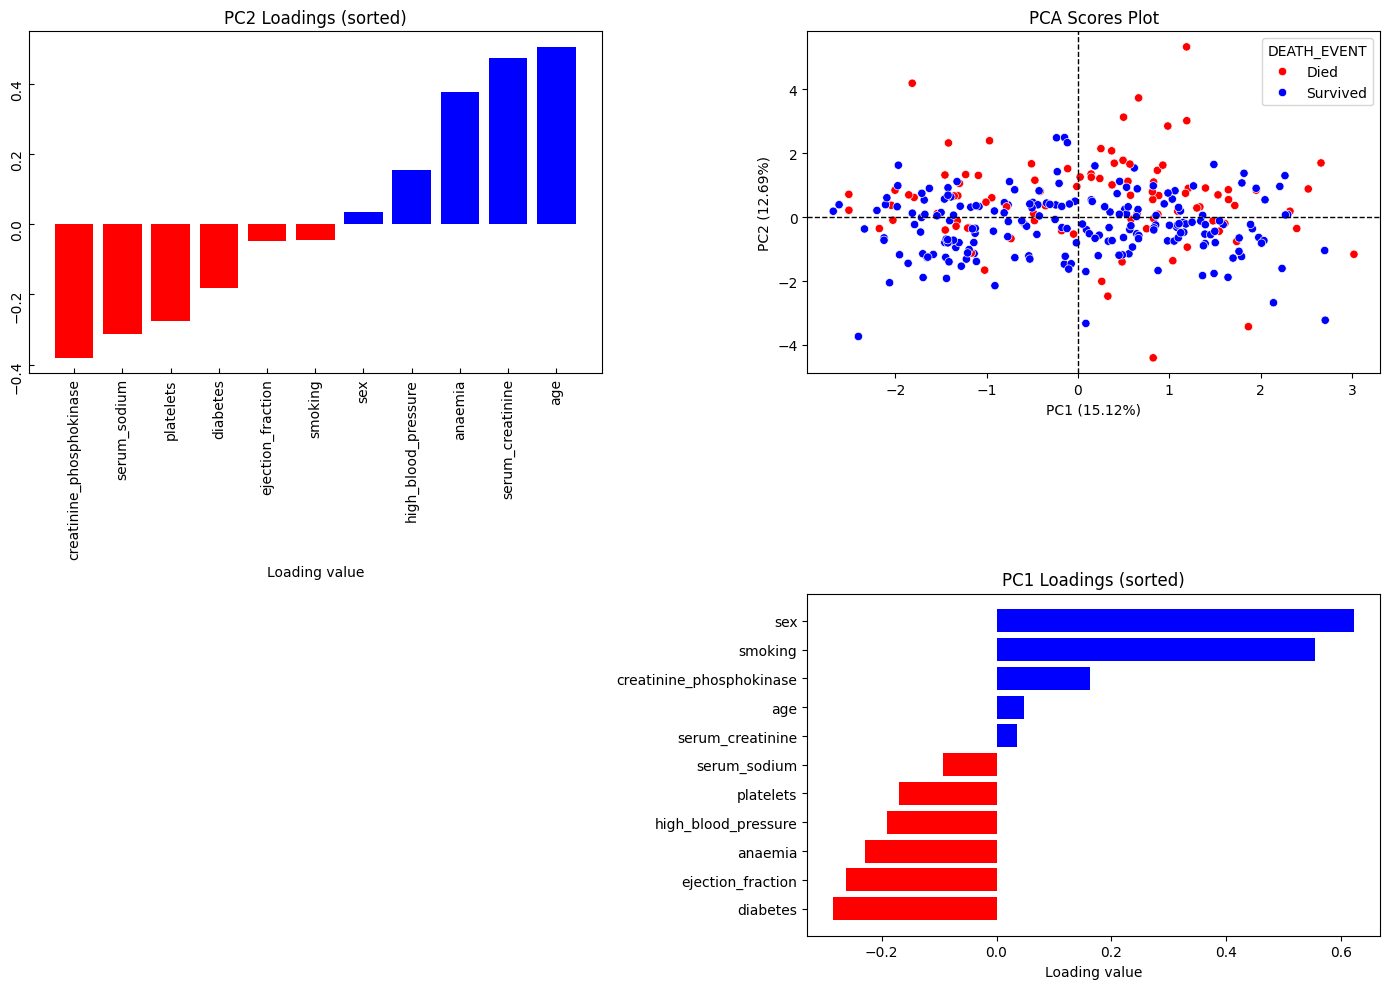

In [182]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
# pca = pca.fit(df_features_zscored)
pca = pca.fit(df_features_new_zscored) # using new version instead
# y= pca.fit_transform(df_features_zscored)
y= pca.fit_transform(df_features_new_zscored)
loadings = pca.components_.T
feature_names = df_features_new.columns

# prepare loadings
pc1_loadings = pd.Series(loadings[:, 0], index=feature_names).sort_values()
pc2_loadings = pd.Series(loadings[:, 1], index=feature_names).sort_values()

pc1_colors = ['red' if v < 0 else 'blue' for v in pc1_loadings]
pc2_colors = ['red' if v < 0 else 'blue' for v in pc2_loadings]

# create 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# (0,0) PC2 loadings
axes[0,0].bar(pc2_loadings.index, pc2_loadings.values, color=pc2_colors)
axes[0,0].set_title('PC2 Loadings (sorted)')
axes[0,0].set_xlabel('Loading value')
axes[0,0].tick_params(axis='both', direction='in',rotation=90)

# (0,1) scores plot
color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y[:,0], y=y[:,1], hue=df_target.map({1: 'Died', 0: 'Survived'}), ax=axes[0,1], palette=color_mapping)
axes[0,1].axhline(0, linestyle='--', linewidth=1, color='black')
axes[0,1].axvline(0, linestyle='--', linewidth=1, color='black')
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0,1].set_title('PCA Scores Plot')

# (1,1) PC1 loadings
axes[1,1].barh(pc1_loadings.index, pc1_loadings.values, color=pc1_colors)
axes[1,1].set_title('PC1 Loadings (sorted)')
axes[1,1].set_xlabel('Loading value')

# (1,0) empty subplot
axes[1,0].axis('off')

plt.tight_layout()
plt.show()

## (3) Cumulative Explained Variance (Scree Plot)

* Scree Plot: visualizes how much variance each principal component explains
* a. Left plot: individual variance explained per PC
* b. Right plot: cumulative variance — shows how many PCs are needed to capture most information
* A common rule of thumb is to keep enough components to explain ~80-90% of the total variance

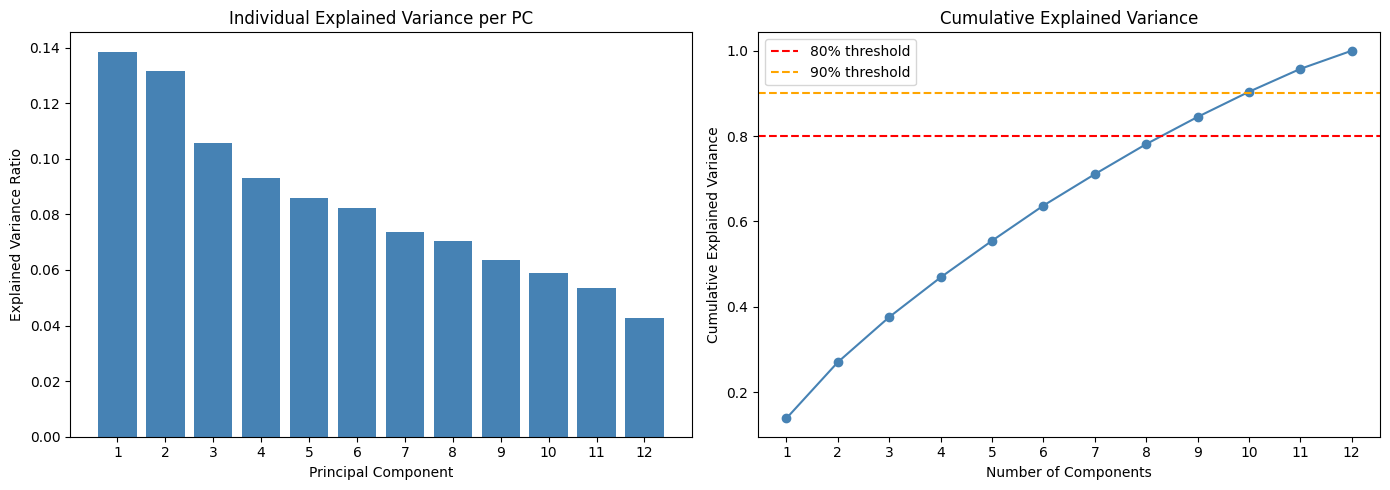

Components needed for 80% variance: 9
Components needed for 90% variance: 10


In [183]:
# fit PCA with all components to see full variance breakdown (all 12 will be shown)
pca_full = PCA().fit(df_features_zscored)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance per PC')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))

# cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue')
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

# print how many components needed for 80% and 90%
for threshold in [0.8, 0.9]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {threshold:.0%} variance: {n_components}")

Conclusion: This dataset does not compress well with PCA — 9 out of 12 components are needed to explain 80% of the variance, suggesting the features are largely independent of each other. For downstream ML modeling, using the original 12 features directly is preferable over a low-dimensional PCA reduction.

## (4) K-Means Clustering

* Now that we can visualize the data in lower dimensions with PCA, let's see if unsupervised clustering can recover the survived/died groups without using the labels.
* (this is unsupervised learning)

In [184]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv')
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']
# exclude the time column for clustering (it's a follow-up period, not a clinical feature)
df_features = df_features.drop(columns=['time'])

# normalize the data
from scipy import stats
df_features_normalized = stats.zscore(df_features)
df_features_normalized = pd.DataFrame(df_features_normalized, columns=df_features.columns)

#KMEANS
from sklearn.cluster import KMeans

# KMeans on scaled feature space (NOT PCA)
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
"""K=2 since we are looking for 2 groups (Died/Survived).
fit_predict trains the model and immediately returns the cluster label for each patient (0 or 1)."""

clusters = kmeans.fit_predict(df_features_normalized)
clusters

# save labels
df_features_normalized['Cluster'] = clusters
df_features_normalized

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,Cluster
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,0
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,0
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,0
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,0
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161,0
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682,1
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682,1
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161,0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


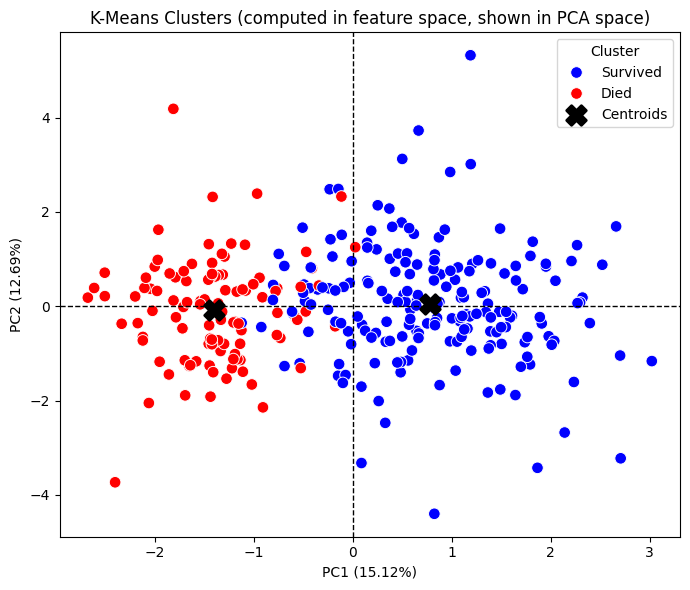

In [185]:
# visualize K-Means clusters in PCA space
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
 
# PCA again to 2D
pca = PCA(n_components=3)
pca = pca.fit(df_features_normalized.iloc[:,:-1])
y= pca.fit_transform(df_features_normalized.iloc[:,:-1])

plt.figure(figsize=(7,6))

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(
    x=y[:,0],
    y=y[:,1],
    hue=df_features_normalized['Cluster'].map({1: 'Died', 0: 'Survived'}), palette=color_mapping,
    s=70
)

# transform cluster centers into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(centers_pca[:,0], centers_pca[:,1], marker='X', s=200, linewidth=2, color='black', label='Centroids')

plt.axhline(0, linestyle='--', linewidth=1, color='black')
plt.axvline(0, linestyle='--', linewidth=1, color='black')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('K-Means Clusters (computed in feature space, shown in PCA space)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

K-Means clusters are computed in the full 12-dimensional feature space, then projected into 2D PCA space purely for visualization.
- PCA is fit on the normalized features (excluding the Cluster column) to get 2D coordinates for each patient
- Each point is colored by its K-Means cluster label (0 → Survived, 1 → Died)
- The two X markers show the cluster centroids, also projected into PCA space

Results:
- The two clusters show partial separation — red points (Died) tend to concentrate on the left side of PC1, while blue points (Survived) dominate the right side, with centroids clearly separated along the PC1 axis.
- However, there is significant overlap between the two groups, meaning K-Means could not cleanly separate Survived vs Died patients.
- This is consistent with the Scree Plot result — PC1 and PC2 together explain only ~28% of total variance, so much information is lost in this 2D projection, and the true separation (if any) likely exists in higher dimensions.

In [186]:
clusters

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0], dtyp

In [187]:
df_target.head(20)

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    0
15    1
16    1
17    1
18    1
19    1
Name: DEATH_EVENT, dtype: int64

[Text(0, 0.5, 'Survived'), Text(0, 1.5, 'Died')]

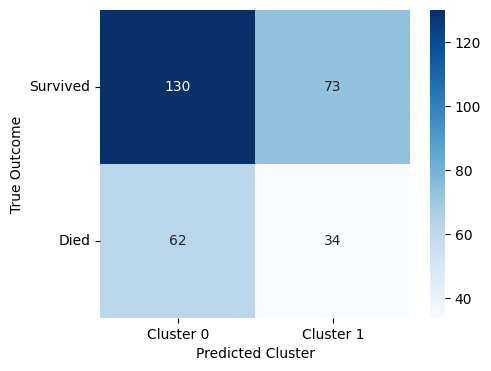

In [188]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df_target, clusters)
import seaborn as sns
# sns.heatmap(cm,annot=True)

plt.figure(figsize=(5,4))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

ax.set_xlabel('Predicted Cluster')
ax.set_ylabel('True Outcome')
ax.set_xticklabels(['Cluster 0', 'Cluster 1'])
ax.set_yticklabels(['Survived', 'Died'], rotation=0)


Results:
- Confusion matrix compares K-Means cluster assignments against the true DEATH_EVENT labels.
- 130 Survived patients → correctly grouped into Cluster 0
-  73 Survived patients → incorrectly placed in Cluster 1
-  62 Died patients    → incorrectly placed in Cluster 0
-  34 Died patients    → correctly grouped into Cluster 1

Overall accuracy: (130+34)/299 = ~54.8% 
K-Means did not meaningfully separate the Survived and Died groups, which is expected given that the features are largely independent (as shown by the Scree Plot) and the two classes overlap heavily in PCA space.

## (4-2)  How to identify the optimal number of K?

Silhouette score = $\frac{b-a}{max(a,b)}$

For each datapoint: 

* a: distance to points in the same cluster

* b: distance to points in other clusters

silhouette score = 1 --> perfect clustering

silhouette score < 0.25 --> weak clustering 



In [189]:
df_features_normalized

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,Cluster
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,0
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,0
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,0
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,0
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161,0
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682,1
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682,1
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161,0


## (5) Silhouette Analysis

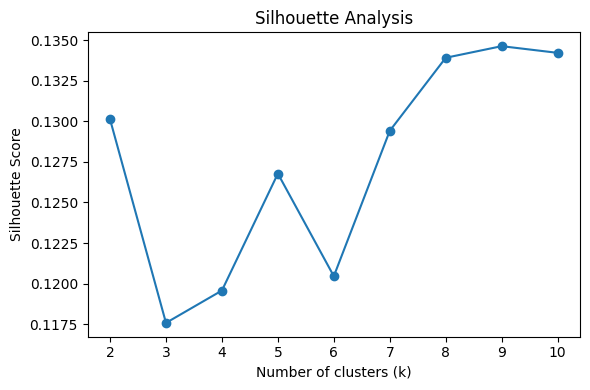

In [190]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
sil_scores = []
K = range(2, 11) # silhouette requires at least 2 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_features_normalized.iloc[:,:-1])
    
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_features_normalized.iloc[:,:-1], labels))

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()


Silhouette analysis runs KMeans for K=2 to 10 and computes the silhouette score for each K
to find the optimal number of clusters.

Results:
- All silhouette scores fall between 0.117 and 0.135 — all well below the 0.25 threshold for
meaningful clustering. This confirms that this dataset does not have strong cluster structure,
regardless of K. 
- The highest score occurs at K=9, but this is not meaningful for our goal
of separating Survived vs Died. K=2 scores second highest (0.130), which is consistent with
our original choice.

## (6) Elbow Method

The **elbow method** plots the **inertia** (within-cluster sum of squares) against the number of clusters K.

$$\text{Inertia} = \sum_{i=1}^{n} \| x_i - c_{k} \|^2$$

where $c_k$ is the centroid of the cluster that point $x_i$ belongs to.

- As K increases, inertia always decreases (more clusters = points closer to centroids)
- The **elbow** is where adding more clusters gives **diminishing returns** -- the curve bends
- Pick the K at the "elbow" of the curve

In [191]:
df_features_normalized.drop(columns=['Cluster'],inplace=True)

In [192]:
df_features_normalized

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682
...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161


In [193]:
# drop cluster column if it exists (added during K-Means section)
if 'Cluster' in df_features_normalized.columns:
    df_features_normalized.drop(columns=['Cluster'], inplace=True)

In [194]:
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
K = range(2, 11)   # silhouette requires at least 2 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_features_normalized)
    
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_features_normalized, labels))


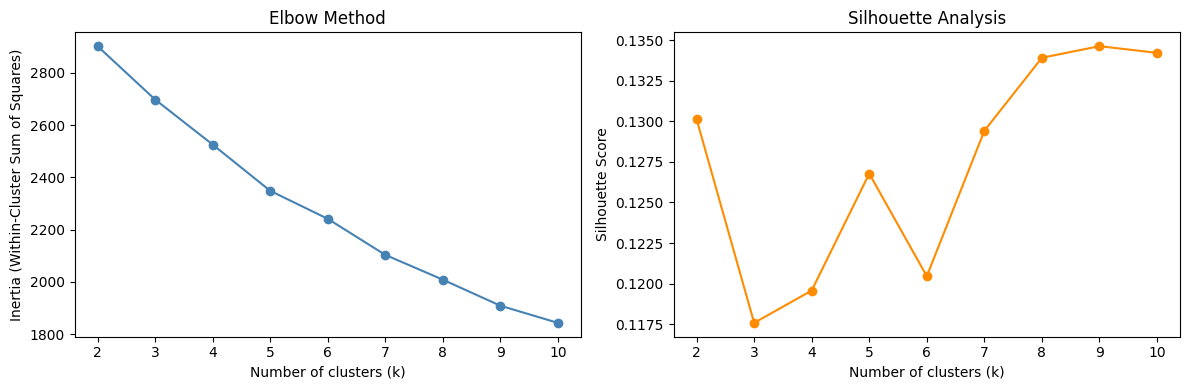

In [195]:
# Elbow plot using the inertia values already computed above
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(K, inertia, marker='o', color='steelblue')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')

# Silhouette plot (side by side for comparison)
axes[1].plot(K, sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

Results:
- Elbow Method shows no clear "elbow" — inertia decreases smoothly without a sharp bend,
suggesting no natural cluster structure in the data.
- Combined with the Silhouette Analysis (all scores below 0.14),
both methods agree: this dataset does not have well-defined clusters,
and K-Means is not an appropriate method for separating Survived vs Died patients.
- This reinforces that supervised learning (using the actual labels) will be necessary
for meaningful classification — which is what we'll do in the next section.

## (7) Hierarchical (Agglomerative) Clustering

**Key differences from K-Means:**
- **Bottom-up** approach: starts with each point as its own cluster, then merges the closest pairs
- Does **not** require specifying K upfront -- you can decide after seeing the **dendrogram**
- Produces a **tree structure** (dendrogram) showing how clusters merge at different distance thresholds
    - K-Means: define K upfront → then cluster
    - Hierarchical: cluster everything first → then decide K from the dendrogram

**Linkage methods** (how to measure distance between clusters):
- `ward`: minimizes the total within-cluster variance (default, tends to produce balanced clusters)
- `complete`: maximum distance between any two points in the two clusters
- `average`: average distance between all pairs of points across the two clusters
- `single`: minimum distance between any two points (can produce elongated chains)

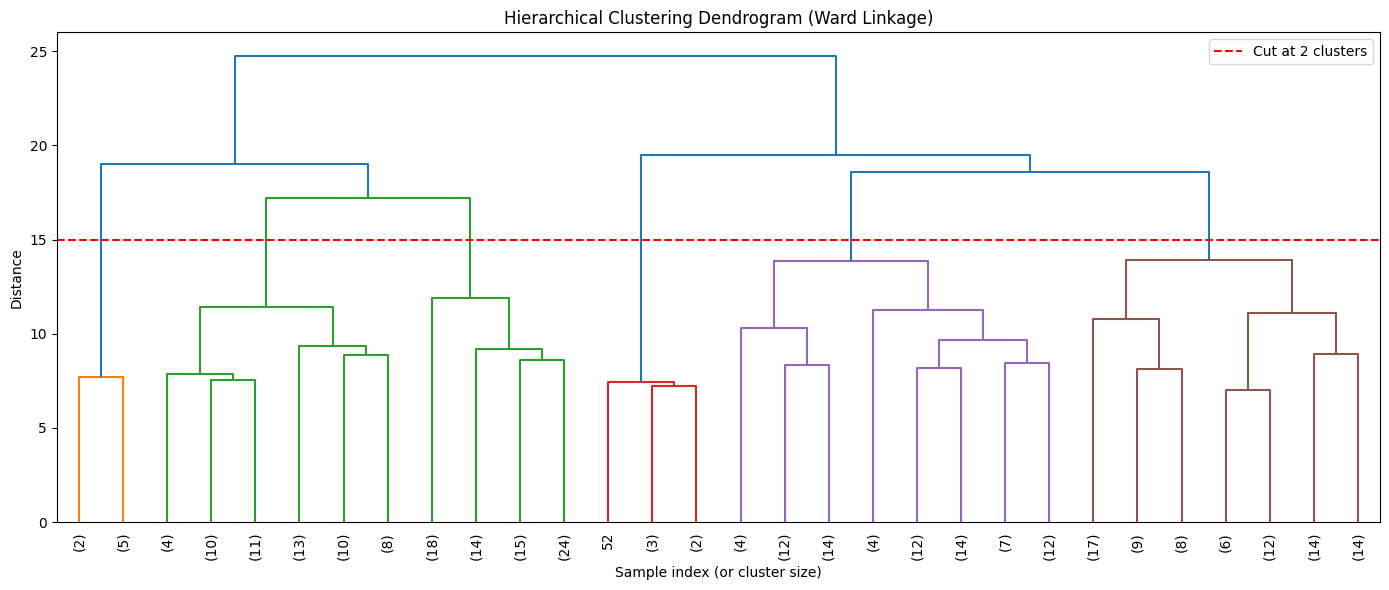

In [196]:
from scipy.cluster.hierarchy import dendrogram, linkage

# compute the linkage matrix using Ward's method
Z = linkage(df_features_normalized, method='ward')

# plot the dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Cut at 2 clusters')
plt.legend()
plt.tight_layout()
plt.show()

In [197]:
from sklearn.cluster import AgglomerativeClustering

# cut the dendrogram at 2 clusters
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = agg.fit_predict(df_features_normalized)

print(f"Cluster 0: {sum(hc_labels == 0)} points")
print(f"Cluster 1: {sum(hc_labels == 1)} points")

Cluster 0: 165 points
Cluster 1: 134 points


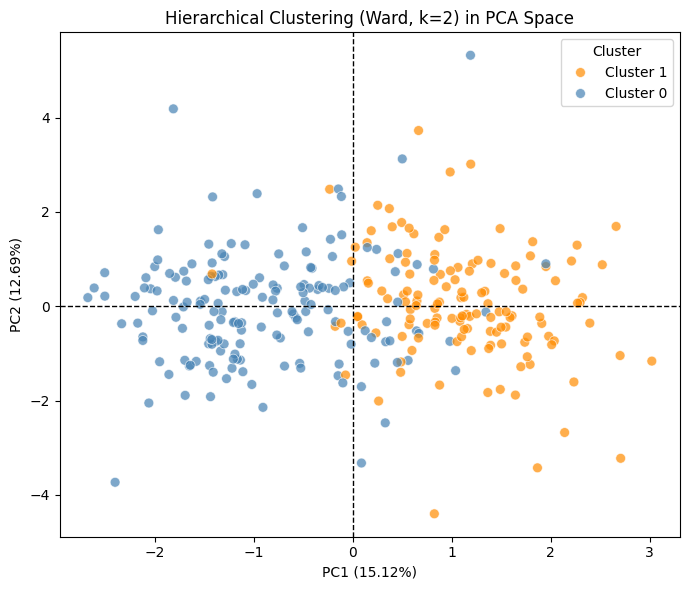

In [198]:
# visualize hierarchical clustering in PCA space
pca_hc = PCA(n_components=2).fit(df_features_normalized)
y_hc = pca_hc.transform(df_features_normalized)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_hc[:, 0], y=y_hc[:, 1],
    hue=pd.Series(hc_labels).map({0: 'Cluster 0', 1: 'Cluster 1'}),
    palette={'Cluster 0': 'steelblue', 'Cluster 1': 'darkorange'},
    s=50, alpha=0.7
)
plt.axhline(0, linestyle='--', linewidth=1, color='black')
plt.axvline(0, linestyle='--', linewidth=1, color='black')
plt.xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Hierarchical Clustering (Ward, k=2) in PCA Space')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## (8) K-Means vs Hierarchical Clustering Comparison

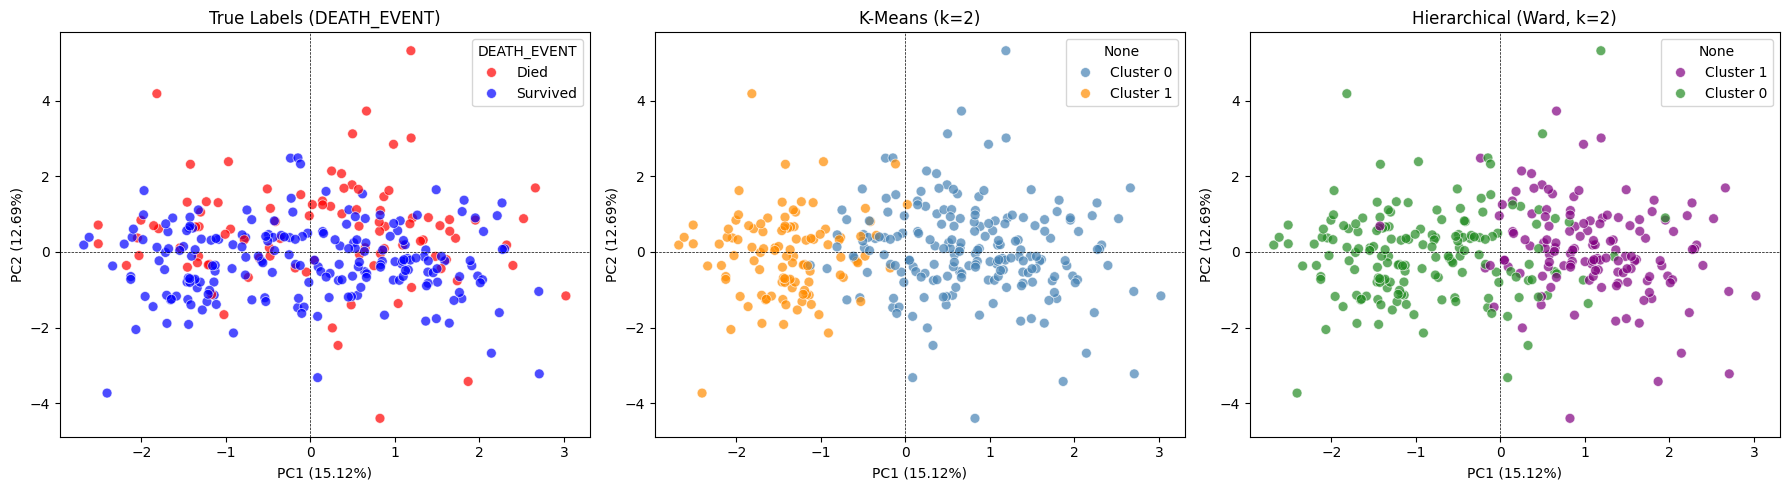

In [199]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# true labels (ground truth)
color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y_hc[:, 0], y=y_hc[:, 1],
                hue=df_target.map({1: 'Died', 0: 'Survived'}),
                palette=color_mapping, ax=axes[0], s=50, alpha=0.7)
axes[0].set_title('True Labels (DEATH_EVENT)')
axes[0].set_xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')

# K-Means clusters
sns.scatterplot(x=y_hc[:, 0], y=y_hc[:, 1],
                hue=pd.Series(clusters).map({0: 'Cluster 0', 1: 'Cluster 1'}),
                palette={'Cluster 0': 'steelblue', 'Cluster 1': 'darkorange'},
                ax=axes[1], s=50, alpha=0.7, legend='full')
axes[1].set_title('K-Means (k=2)')
axes[1].set_xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')

# Hierarchical clusters
sns.scatterplot(x=y_hc[:, 0], y=y_hc[:, 1],
                hue=pd.Series(hc_labels).map({0: 'Cluster 0', 1: 'Cluster 1'}),
                palette={'Cluster 0': 'forestgreen', 'Cluster 1': 'purple'},
                ax=axes[2], s=50, alpha=0.7, legend='full')
axes[2].set_title('Hierarchical (Ward, k=2)')
axes[2].set_xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
axes[2].set_ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')

for ax in axes:
    ax.axhline(0, linestyle='--', linewidth=0.5, color='black')
    ax.axvline(0, linestyle='--', linewidth=0.5, color='black')

plt.tight_layout()
plt.show()

Results:
- Both K-Means and Hierarchical clustering produce a similar left/right split along PC1,
loosely aligning with the True Labels. 
- However, significant overlap remains in both results,
confirming that unsupervised clustering cannot cleanly separate Survived vs Died in this dataset.
- Supervised learning with actual labels will be needed for meaningful classification.

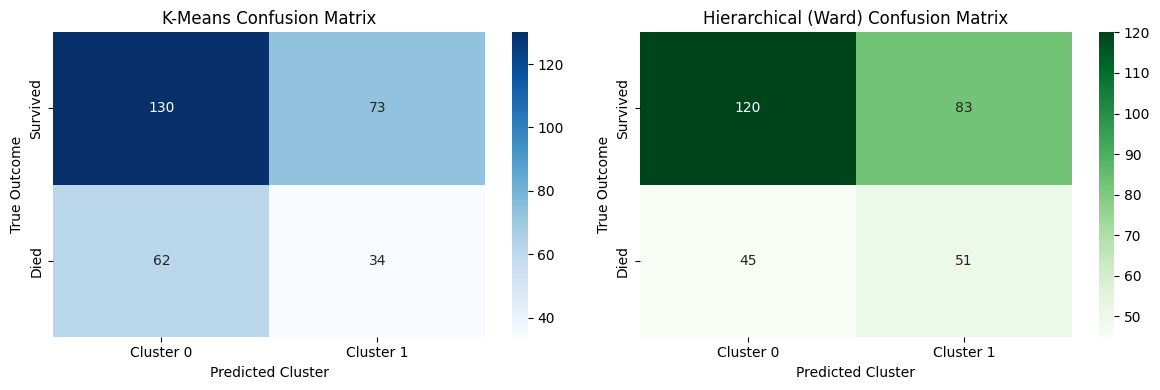

In [200]:
# comparing confusion matrices of K-means and Hierarchial CLustering (to see which better recovers the true survived/died groups)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# K-Means confusion matrix
cm_km = confusion_matrix(df_target, clusters)
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Survived', 'Died'])
axes[0].set_xlabel('Predicted Cluster')
axes[0].set_ylabel('True Outcome')
axes[0].set_title('K-Means Confusion Matrix')

# Hierarchical confusion matrix
cm_hc = confusion_matrix(df_target, hc_labels)
sns.heatmap(cm_hc, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Survived', 'Died'])
axes[1].set_xlabel('Predicted Cluster')
axes[1].set_ylabel('True Outcome')
axes[1].set_title('Hierarchical (Ward) Confusion Matrix')

plt.tight_layout()
plt.show()

In [201]:
# statistical analysis of normalized data
from scipy.stats import ttest_ind

survived = df_target == 0
died = df_target == 1

results_norm = []
results_raw = []

# df_features_normalized has 'Cluster' column added — exclude it
feature_cols = [col for col in df_features_normalized.columns if col != 'Cluster']

for col in feature_cols:
    t_stat_n, p_val_n = ttest_ind(df_features_normalized.loc[survived, col],
                                   df_features_normalized.loc[died, col], equal_var=False)
    t_stat_r, p_val_r = ttest_ind(df_features_new.loc[survived, col],
                                   df_features_new.loc[died, col], equal_var=False)
    results_norm.append({'Feature': col, 'P-Value (normalized)': p_val_n})
    results_raw.append({'Feature': col, 'P-Value (raw)': p_val_r})

comparison = pd.DataFrame(results_norm)
comparison['P-Value (raw)'] = [r['P-Value (raw)'] for r in results_raw]
comparison['Difference'] = abs(comparison['P-Value (normalized)'] - comparison['P-Value (raw)'])
comparison = comparison.sort_values('P-Value (normalized)')

print(comparison.to_string(index=False))
print("\nThe p-values are IDENTICAL. Z-scoring is a linear transformation")
print("(subtract mean, divide by std). It does not change the t-statistic")
print("because both numerator and denominator scale by the same factor.")

                 Feature  P-Value (normalized)  P-Value (raw)   Difference
       ejection_fraction              0.000010       0.000010 0.000000e+00
                     age              0.000047       0.000047 9.215718e-19
        serum_creatinine              0.000064       0.000064 3.523657e-19
            serum_sodium              0.001872       0.001872 5.095750e-17
     high_blood_pressure              0.179564       0.179564 5.551115e-17
                 anaemia              0.257064       0.257064 3.885781e-16
creatinine_phosphokinase              0.369216       0.369216 5.551115e-17
               platelets              0.399323       0.399323 8.881784e-16
                 smoking              0.827535       0.827535 1.110223e-16
                     sex              0.940901       0.940901 6.661338e-16
                diabetes              0.973345       0.973345 3.330669e-16

The p-values are IDENTICAL. Z-scoring is a linear transformation
(subtract mean, divide by std). It

## (9) Summary

**Key Takeaways:**

1. **Data Normalization**: Z-score standardization is essential before PCA and clustering so that high-variance features (e.g., platelets, creatinine_phosphokinase) don't dominate
2. **PCA**: Reduces dimensionality while preserving variance. Cumulative explained variance plots help decide how many components to keep
3. **K-Means**: Partitions data into K spherical clusters. Requires choosing K in advance using the **elbow method** (inertia) or **silhouette scores**
4. **Hierarchical Clustering**: Bottom-up approach that produces a dendrogram. No need to pick K upfront -- cut the tree at different heights to explore different groupings. Linkage method choice affects cluster shape
5. **K-Means vs Hierarchical**: K-Means is fast but requires K upfront and is sensitive to initialization. Hierarchical is deterministic and gives a full tree of merge history, but is slower on large datasets
6. **Confusion Matrix**: Useful for comparing unsupervised clusters against known labels, even though clustering is unsupervised

**Next Steps**: Supervised learning -- using the labeled data to build predictive models

## (10) Resources

**Data Normalization:**
- [Scikit-learn Preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [Z-score vs Min-Max Scaling](https://www.analyticsvidhya.com/blog/2020/04/feature-scaling-machine-learning-normalization-standardization/)

**PCA:**
- [Scikit-learn PCA Documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [StatQuest: PCA Explained](https://www.youtube.com/watch?v=FgakZw6K1QQ)
- [PCA and Eigenvectors](https://www.youtube.com/watch?v=C21GoH0Y9AE)

**K-Means:**
- [Scikit-learn KMeans](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [Elbow Method Explained](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/)
- [Silhouette Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

**Hierarchical Clustering:**
- [Scikit-learn Agglomerative Clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering)
- [Scipy Dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html)
- [StatQuest: Hierarchical Clustering](https://www.youtube.com/watch?v=7xHsRkOdVwo)

**Confusion Matrix:**
- [Scikit-learn Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)